# Batch effects across models: CLS vs. central token

For each model in `MODELS` below, this loads per-cell embeddings for the **CLS
token** (alone) and a **central token** -- the mean of the four central grid
tokens (`top_left`, `top_right`, `bottom_left`, `bottom_right`, the fixed
`patches_to_save` every `InferenceProvider` saves alongside CLS, see e.g.
`src/python/extract_embeddings/inference_providers/uni2_inference_provider.py`),
averaged together the same way `compare_embeddings_across_extractions.ipynb`'s
`add_central_token` does -- then asks: **how much does each of these two
token's embedding encode H&E slide-of-origin ("batch") vs. biological cell
identity?**

Batch = `wsi` (the H&E slide a cell came from); biology = `cell_type` (mapped
cell label, see `src/python/code_configs/mappings.py`). Two kinds of evidence,
per (model, token):

**Visual**
- PCA (top-2 PCs) and UMAP (2D, computed on a PCA pre-reduction), each colored
  once by `wsi` and once by `cell_type`. Clusters that track `wsi` but not
  `cell_type` are the visual signature of a batch effect.

**Quantitative** (batch effect = "how strongly `wsi` is encoded"; biological
signal = "how strongly `cell_type` is encoded" -- both computed the same way,
just with a different covariate)
- **PCR** (principal component regression): variance-ratio-weighted R2 of a
  linear regression of each top PC onto the covariate (one-hot encoded) --
  i.e. what fraction of the embedding's own variance that covariate explains.
  `pcr_batch` **lower = less batch effect**; `pcr_cell_type` **higher = more
  retained biological signal**. No extra dependency (`sklearn.PCA` +
  `sklearn.LinearRegression`), same definition scIB uses for its PCR metric
  (Buttner et al. 2019 / Luecken et al. 2022).
- **iLISI** / **cLISI** (Local Inverse Simpson Index, Korsunsky et al. 2019 --
  the statistic scIB's integration benchmarks are built on): for each cell, a
  perplexity-weighted neighborhood mixing score. Raw LISI ranges `[1,
  n_categories]`; we report the median raw value plus the `[0, 1]`-scaled
  version `(median - 1) / (n_categories - 1)`.
    - `ilisi_scaled` (batch=`wsi`): **higher = better mixing across slides =
      less batch effect**.
    - `clisi_scaled` (bio=`cell_type`): **lower = cell types stay separated**
      (well-preserved biological structure); we also report `clisi_score = 1 -
      clisi_scaled` so it sits on the same "higher is better" axis as
      `ilisi_scaled` in the summary bar charts.
    - Needs `harmonypy` (`pip install harmonypy`) -- if it isn't installed,
      these two are skipped and everything else (PCA/UMAP, PCR) still runs.

See **Extending this notebook** at the bottom for how to add another
model/token, restrict to specific WSIs, or fold in the boundary-pooled
`embeddings_cell` / `embeddings_nucleus` tokens.


In [1]:
import os
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(REPO_ROOT))


def _load_dotenv(path: Path) -> None:
    """Minimal `.env` loader (KEY=value per line) -- avoids an extra dependency.
    Mirrors how every other entry point in this repo expects env vars to be set
    (see src/python/code_configs/paths.py)."""
    if not path.exists():
        return
    for line in path.read_text().splitlines():
        line = line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, _, value = line.partition("=")
        key, value = key.strip(), value.strip()
        if value:
            os.environ.setdefault(key, value)


_load_dotenv(REPO_ROOT / ".env")


In [2]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

from src.python.code_configs import paths
from src.python.code_configs.mappings import mapping_factory

try:
    import umap
    _HAVE_UMAP = True
except ImportError:
    _HAVE_UMAP = False
    print("umap-learn is not installed (`pip install umap-learn`) -- UMAP panels below "
          "will be skipped; PCA panels still work without it.")

try:
    from harmonypy import compute_lisi as _harmonypy_compute_lisi
    _HAVE_LISI = True
except ImportError:
    _HAVE_LISI = False
    print("harmonypy is not installed (`pip install harmonypy`) -- iLISI/cLISI will be "
          "skipped; PCA/UMAP and PCR still work without it.")

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)


## Config -- models & tokens

`DATASETS_ROOT / "{model_output_dir}_h5" / CORRECTION_NAME / {wsi} /
embeddings_dataset.h5` is the layout `extract_embeddings.py` writes (see
`src/python/code_configs/paths.py`); `CORRECTION_NAME` is the same "raw" used
throughout the other notebooks (nothing else has been written under
`DATASETS_ROOT` yet, per `probing_colon.yaml`'s own comment about that path
segment).

`MODELS` maps a short key (used in every plot title / summary row) to the
`{model_output_dir}` half of that folder name -- one entry per model requested
for this comparison. **To add another model**, add a key here; if its
`{model}_h5` root doesn't exist, or is missing `cls` and/or one of
`CORNER_KEYS`, the loading cell below reports it and continues with whatever's
available (`cls` alone, `central` alone, or neither) rather than failing the
whole run.


In [3]:
DATASETS_ROOT = Path(paths.DATASETS_ROOT)
CORRECTION_NAME = "raw"

MAPPING_NAME = "simplified_broad"  # any key in src/python/code_configs/mappings.py
MAPPING = mapping_factory(MAPPING_NAME)

SEED = 42

# The four grid tokens InferenceProvider.patches_to_save saves alongside cls -- averaged
# together (add_central_token below) into one "central" token, so the comparison below
# is exactly "cls alone" vs. "central alone", not each corner individually. See
# "Extending this notebook" to instead keep the four corners separate.
CORNER_KEYS = ["top_left", "top_right", "bottom_left", "bottom_right"]

# The two tokens actually compared throughout this notebook: cls (raw embeddings_cls)
# and central (derived -- see add_central_token below).
TOKEN_KEYS = ["cls", "central"]

# model_key -> {model_output_dir} (the part of "{model_output_dir}_h5" before the
# suffix) -- see build_configs / build_resized_cell_configs in extract_embeddings.py.
# Edit these if your actual h5 roots use different names.
MODELS = {
    "UNI2_448_resized": "UNI2_448_resized",
    "HOptimus1":        "HOptimus1",
    "UNI2":             "UNI2",
    "virchow_v2":       "virchow_v2",
    "UNI2_resized":     "UNI2_resized",
    "UNI2_100_resized": "UNI2_100_resized",
    "PhikonV2_448":     "PhikonV2_448",
}

# None = auto-discover every WSI subdirectory with an embeddings_dataset.h5 for each
# model, then restrict to the WSIs common to every model below, so every model's
# metrics/plots are computed on the exact same cell population. Set explicitly (a list
# of WSI folder names) to skip discovery and force a specific cohort.
WSI_LIST = None


## Loading

`discover_wsis` / `available_raw_keys` / `load_tokens` mirror
`notebooks/compare_embeddings_across_extractions.ipynb`'s loading helpers,
loading the *raw* h5 datasets each `central` needs (`CORNER_KEYS`) plus `cls`;
`add_central_token` (identical to that notebook's helper of the same name)
then mean-pools `CORNER_KEYS` into `central` and the raw corners are dropped --
`MODEL_DATA` only ever holds `cls` / `central` downstream. `available_raw_keys`
checks which of those *raw* keys actually exist for a given model (by peeking
at its first WSI's h5 file), so a model missing `cls`, or missing any one of
`CORNER_KEYS` (which means `central` can't be built at all), degrades
gracefully -- it just ends up with whichever of `cls` / `central` it could
construct, instead of raising.

`cell_labels` are looked up through `MAPPING` exactly like
`src/python/utils/loading_functions.py` does for the probing/classifier
pipelines (mapping dict keys are raw `bytes`, matching what h5py hands back
for a variable-length utf-8 dataset read without `.asstr()`).


In [4]:
def discover_wsis(h5_root: Path) -> list[str]:
    """Every subdirectory of `h5_root` holding an embeddings_dataset.h5."""
    return sorted(p.name for p in Path(h5_root).iterdir() if (p / "embeddings_dataset.h5").is_file())


def available_raw_keys(h5_root: Path, wsi_list: list[str], raw_keys: list[str]) -> list[str]:
    """Which of `raw_keys` have an embeddings_{key} dataset in `h5_root`'s first WSI --
    lets a model missing some of them (e.g. no cls, or a partial corner set) degrade
    gracefully instead of raising a KeyError deep inside load_tokens."""
    probe_path = Path(h5_root) / wsi_list[0] / "embeddings_dataset.h5"
    with h5py.File(probe_path, "r") as f:
        present = {k for k in raw_keys if f"embeddings_{k}" in f}
    missing = [k for k in raw_keys if k not in present]
    if missing:
        print(f"  [warning] {h5_root}: missing raw token(s) {missing} (checked against "
              f"{wsi_list[0]}) -- anything derived from them will be skipped for this model.")
    return [k for k in raw_keys if k in present]


def load_tokens(h5_root: Path, raw_keys: list[str], wsi_list: list[str],
                 mapping: dict) -> tuple[dict[str, np.ndarray], pd.DataFrame]:
    """Load `embeddings_{key}` for every key in `raw_keys`, for every WSI in `wsi_list`,
    under `h5_root`.

    Returns:
        tokens: {raw_key: (N, D) float32 array}, same row order as `meta`.
        meta: DataFrame with columns cell_id, wsi, cell_label_raw, cell_type -- cell_type
            is cell_label_raw passed through `mapping`.
    """
    tokens: dict[str, list[np.ndarray]] = {k: [] for k in raw_keys}
    meta_rows = []

    for wsi in wsi_list:
        h5_path = Path(h5_root) / wsi / "embeddings_dataset.h5"
        with h5py.File(h5_path, "r") as f:
            cell_ids = f["cell_ids"][()]
            cell_labels = f["cell_labels"][()]  # raw bytes -- matches mappings.py's bytes-keyed dicts
            for key in raw_keys:
                tokens[key].append(f[f"embeddings_{key}"][()])

        cell_ids_dec = [c.decode("utf-8") if isinstance(c, bytes) else c for c in cell_ids]
        cell_label_raw = [l.decode("utf-8") if isinstance(l, bytes) else l for l in cell_labels]
        cell_type = [mapping.get(l, "Unknown") for l in cell_labels]
        meta_rows.append(pd.DataFrame({
            "cell_id": cell_ids_dec, "wsi": wsi,
            "cell_label_raw": cell_label_raw, "cell_type": cell_type,
        }))

    meta = pd.concat(meta_rows, ignore_index=True)
    tokens = {k: np.concatenate(v, axis=0) for k, v in tokens.items()}
    return tokens, meta


def add_central_token(tokens: dict[str, np.ndarray], corner_keys: list[str] = CORNER_KEYS,
                       out_key: str = "central") -> dict[str, np.ndarray]:
    """Mean-pool `corner_keys` into a new `out_key` entry (doesn't mutate `tokens`) --
    identical to compare_embeddings_across_extractions.ipynb's helper of the same name.
    No-op (returns `tokens` unchanged) if any `corner_keys` entry is missing, e.g. this
    model's h5 root didn't have every corner token available."""
    if not all(k in tokens for k in corner_keys):
        return tokens
    tokens = dict(tokens)
    tokens[out_key] = np.mean([tokens[k] for k in corner_keys], axis=0)
    return tokens


In [5]:
MODEL_DATA = {}  # model_key -> {"tokens": {token: (N,D) array}, "meta": df, "h5_root": Path}

_per_model_wsis = {}
for model_key, model_output_dir in MODELS.items():
    h5_root = DATASETS_ROOT / f"{model_output_dir}_h5" / CORRECTION_NAME
    if not Path(h5_root).is_dir():
        print(f"[skip] {model_key}: {h5_root} does not exist.")
        continue
    _per_model_wsis[model_key] = (h5_root, discover_wsis(h5_root))

assert _per_model_wsis, "None of MODELS' h5 roots exist under DATASETS_ROOT -- check paths.DATASETS_ROOT / MODELS / CORRECTION_NAME."

if WSI_LIST is None:
    common_wsis = set.intersection(*(set(wsis) for _, wsis in _per_model_wsis.values()))
    for model_key, (_, wsis) in _per_model_wsis.items():
        extra = set(wsis) - common_wsis
        if extra:
            print(f"[note] {model_key} has {len(extra)} WSI(s) not shared by every model "
                  f"-- excluded from this run: {sorted(extra)}")
    resolved_wsi_list = sorted(common_wsis)
else:
    resolved_wsi_list = WSI_LIST

assert resolved_wsi_list, ("No WSI is common to every model in MODELS -- set WSI_LIST "
                            "explicitly, or narrow MODELS down, to fix this.")
print(f"Using {len(resolved_wsi_list)} WSI(s) common to every model: {resolved_wsi_list}\n")

RAW_KEYS_NEEDED = sorted(set(CORNER_KEYS) | {"cls"})

for model_key, (h5_root, _) in _per_model_wsis.items():
    raw_keys = available_raw_keys(h5_root, resolved_wsi_list, RAW_KEYS_NEEDED)
    if not raw_keys:
        print(f"[skip] {model_key}: none of {RAW_KEYS_NEEDED} available.")
        continue
    raw_tokens, meta = load_tokens(h5_root, raw_keys, resolved_wsi_list, MAPPING)
    tokens = add_central_token(raw_tokens)
    tokens = {k: v for k, v in tokens.items() if k in TOKEN_KEYS}  # keep cls/central only
    if not tokens:
        print(f"[skip] {model_key}: neither {TOKEN_KEYS} could be constructed from {raw_keys}.")
        continue
    MODEL_DATA[model_key] = dict(tokens=tokens, meta=meta, h5_root=h5_root)
    print(f"[{model_key}] {len(meta):,} cells across {meta['wsi'].nunique()} WSI(s) -- "
          f"tokens={sorted(tokens)}; cell types={sorted(meta['cell_type'].unique())}")


[note] UNI2_448_resized has 4 WSI(s) not shared by every model -- excluded from this run: ['Xenium_V1_Human_Colon_Cancer_P1_CRC_Add_on_FFPE', 'Xenium_V1_Human_Colon_Cancer_P5_CRC_Add_on_FFPE', 'Xenium_V1_hColon_Cancer_Add_on_FFPE', 'Xenium_V1_hColon_Non_diseased_Base_FFPE']
[note] HOptimus1 has 19 WSI(s) not shared by every model -- excluded from this run: ['GSM7990532', 'GSM7990533', 'GSM7990534', 'GSM7990537', 'GSM7990540', 'GSM7990541', 'GSM7990543', 'GSM7990549', 'GSM7990550', 'GSM7990551', 'GSM7990554', 'GSM7990556', 'GSM7990557', 'GSM7990558', 'GSM7990559', 'Xenium_V1_Human_Colon_Cancer_P1_CRC_Add_on_FFPE', 'Xenium_V1_Human_Colon_Cancer_P5_CRC_Add_on_FFPE', 'Xenium_V1_hColon_Cancer_Add_on_FFPE', 'Xenium_V1_hColon_Non_diseased_Base_FFPE']
[note] UNI2 has 36 WSI(s) not shared by every model -- excluded from this run: ['GSM7990532', 'GSM7990533', 'GSM7990534', 'GSM7990537', 'GSM7990540', 'GSM7990541', 'GSM7990543', 'GSM7990549', 'GSM7990550', 'GSM7990551', 'GSM7990554', 'GSM7990556'

## Quantitative: PCR + iLISI/cLISI, per (model, token)

Both metrics operate on a shared PCA reduction (`N_PCA_COMPS` components) of
each (model, token)'s raw embedding matrix -- standard practice for LISI on
high-dimensional ViT embeddings (same idea as `compare_embeddings_across_
extractions.ipynb`'s `pca_components_for_umap` before UMAP), and it keeps PCR
and LISI comparable since they see the same reduced representation.
`N_SUBSAMPLE_METRICS` caps how many cells feed both (LISI's kNN search and
PCR's per-PC regressions scale with n_cells) -- set to `None` to use every
cell.


In [6]:
N_PCA_COMPS = 50
LISI_PERPLEXITY = 30
N_SUBSAMPLE_METRICS = 20_000


def subsample_index(n_total: int, n: int | None, seed: int = SEED) -> np.ndarray:
    if n is None or n >= n_total:
        return np.arange(n_total)
    return np.random.default_rng(seed).choice(n_total, size=n, replace=False)


def pca_reduce(X: np.ndarray, n_comps: int = N_PCA_COMPS, seed: int = SEED):
    n_comps = min(n_comps, X.shape[1], X.shape[0] - 1)
    pca = PCA(n_components=n_comps, random_state=seed).fit(X)
    return pca.transform(X), pca.explained_variance_ratio_


def principal_component_regression(X_pca: np.ndarray, var_ratio: np.ndarray,
                                    covariate: pd.Series) -> float:
    """scIB-style PCR: variance-ratio-weighted R^2 of a linear regression of each PC
    onto `covariate` (one-hot encoded) -- the fraction of the embedding's own variance
    explained by that covariate. Lower is better for a batch covariate (less batch
    effect); higher is better for a biological covariate like cell_type (more retained
    signal). 0.0 if `covariate` has a single category (nothing to explain)."""
    dummies = pd.get_dummies(covariate.astype(str)).to_numpy(dtype=float)
    if dummies.shape[1] <= 1:
        return 0.0
    r2_per_pc = np.empty(X_pca.shape[1])
    for i in range(X_pca.shape[1]):
        reg = LinearRegression().fit(dummies, X_pca[:, i])
        r2_per_pc[i] = max(reg.score(dummies, X_pca[:, i]), 0.0)
    return float(np.sum(var_ratio * r2_per_pc))


def lisi_scores(X_pca: np.ndarray, meta: pd.DataFrame, perplexity: int = LISI_PERPLEXITY) -> dict:
    """Median raw LISI + [0,1]-scaled LISI for `wsi` (batch, -> ilisi_*) and
    `cell_type` (bio, -> clisi_*), via harmonypy.compute_lisi (Korsunsky et al. 2019's
    neighborhood Simpson's-index statistic -- the one scIB's own iLISI/cLISI are built
    on). Returns {} if harmonypy isn't installed."""
    if not _HAVE_LISI:
        return {}
    label_cols = ["wsi", "cell_type"]
    lisi_arr = _harmonypy_compute_lisi(X_pca, meta, label_cols, perplexity=perplexity)
    out = {}
    for i, (col, kind, count_key) in enumerate([("wsi", "ilisi", "n_batches"),
                                                 ("cell_type", "clisi", "n_cell_types")]):
        n_cat = meta[col].nunique()
        raw_median = float(np.median(lisi_arr[:, i]))
        scaled = (raw_median - 1.0) / max(n_cat - 1, 1)
        out[f"{kind}_raw_median"] = raw_median
        out[f"{kind}_scaled"] = scaled
        out[count_key] = n_cat
    out["clisi_score"] = 1.0 - out["clisi_scaled"]  # higher-is-better, next to ilisi_scaled
    return out


In [7]:
METRIC_ROWS = []
for model_key, data in MODEL_DATA.items():
    meta_full = data["meta"]
    idx = subsample_index(len(meta_full), N_SUBSAMPLE_METRICS)
    meta = meta_full.iloc[idx].reset_index(drop=True)
    for token in TOKEN_KEYS:
        if token not in data["tokens"]:
            continue
        X = data["tokens"][token][idx]
        X_pca, var_ratio = pca_reduce(X)

        row = dict(model=model_key, token=token, n_cells=len(meta),
                   n_wsi=meta["wsi"].nunique(), n_cell_types=meta["cell_type"].nunique())
        row["pcr_batch"] = principal_component_regression(X_pca, var_ratio, meta["wsi"])
        row["pcr_cell_type"] = principal_component_regression(X_pca, var_ratio, meta["cell_type"])
        row.update(lisi_scores(X_pca, meta))
        METRIC_ROWS.append(row)

        msg = f"[{model_key}/{token}] pcr_batch={row['pcr_batch']:.4f}  pcr_cell_type={row['pcr_cell_type']:.4f}"
        if _HAVE_LISI:
            msg += f"  ilisi_scaled={row['ilisi_scaled']:.4f}  clisi_score={row['clisi_score']:.4f}"
        print(msg)

metrics_df = pd.DataFrame(METRIC_ROWS)
metrics_df.round(4)


[UNI2_448_resized/cls] pcr_batch=0.3144  pcr_cell_type=0.0335  ilisi_scaled=0.0000  clisi_score=0.8619
[UNI2_448_resized/central] pcr_batch=0.1037  pcr_cell_type=0.0902  ilisi_scaled=0.0408  clisi_score=0.9263
[HOptimus1/cls] pcr_batch=0.2363  pcr_cell_type=0.0394  ilisi_scaled=0.0000  clisi_score=0.9004
[HOptimus1/central] pcr_batch=0.0561  pcr_cell_type=0.0518  ilisi_scaled=0.0793  clisi_score=0.9381
[UNI2/cls] pcr_batch=0.2255  pcr_cell_type=0.0353  ilisi_scaled=0.0000  clisi_score=0.8924
[UNI2/central] pcr_batch=0.0834  pcr_cell_type=0.0935  ilisi_scaled=0.0854  clisi_score=0.9459
[virchow_v2/cls] pcr_batch=0.2976  pcr_cell_type=0.0587  ilisi_scaled=0.0000  clisi_score=0.8933
[virchow_v2/central] pcr_batch=0.1833  pcr_cell_type=0.1286  ilisi_scaled=0.0861  clisi_score=0.9213
[UNI2_resized/cls] pcr_batch=0.1683  pcr_cell_type=0.0179  ilisi_scaled=0.1190  clisi_score=0.7849
[UNI2_resized/central] pcr_batch=0.0890  pcr_cell_type=0.0156  ilisi_scaled=0.2760  clisi_score=0.7324
[UNI2_10

,model,token,n_cells,n_wsi,n_cell_types,pcr_batch,pcr_cell_type,ilisi_raw_median,ilisi_scaled,n_batches,clisi_raw_median,clisi_scaled,clisi_score
0,UNI2_448_resized,cls,20000,7,5,0.3144,0.0335,1.0000,0.0000,7,1.5524,0.1381,0.8619
1,UNI2_448_resized,central,20000,7,5,0.1037,0.0902,1.2447,0.0408,7,1.2947,0.0737,0.9263
2,HOptimus1,cls,20000,7,5,0.2363,0.0394,1.0000,0.0000,7,1.3983,0.0996,0.9004
3,HOptimus1,central,20000,7,5,0.0561,0.0518,1.4760,0.0793,7,1.2475,0.0619,0.9381
4,UNI2,cls,20000,7,5,0.2255,0.0353,1.0000,0.0000,7,1.4305,0.1076,0.8924
5,UNI2,central,20000,7,5,0.0834,0.0935,1.5121,0.0854,7,1.2163,0.0541,0.9459
6,virchow_v2,cls,20000,7,5,0.2976,0.0587,1.0000,0.0000,7,1.4268,0.1067,0.8933
7,virchow_v2,central,20000,7,5,0.1833,0.1286,1.5165,0.0861,7,1.3147,0.0787,0.9213
8,UNI2_resized,cls,20000,7,5,0.1683,0.0179,1.7138,0.1190,7,1.8604,0.2151,0.7849
9,UNI2_resized,central,20000,7,5,0.0890,0.0156,2.6561,0.2760,7,2.0703,0.2676,0.7324


## Quantitative summary plots

Grouped bar charts, one bar group per model, one bar per token within the
group -- directly comparable across `MODELS` since every model was restricted
to the same WSI cohort above.


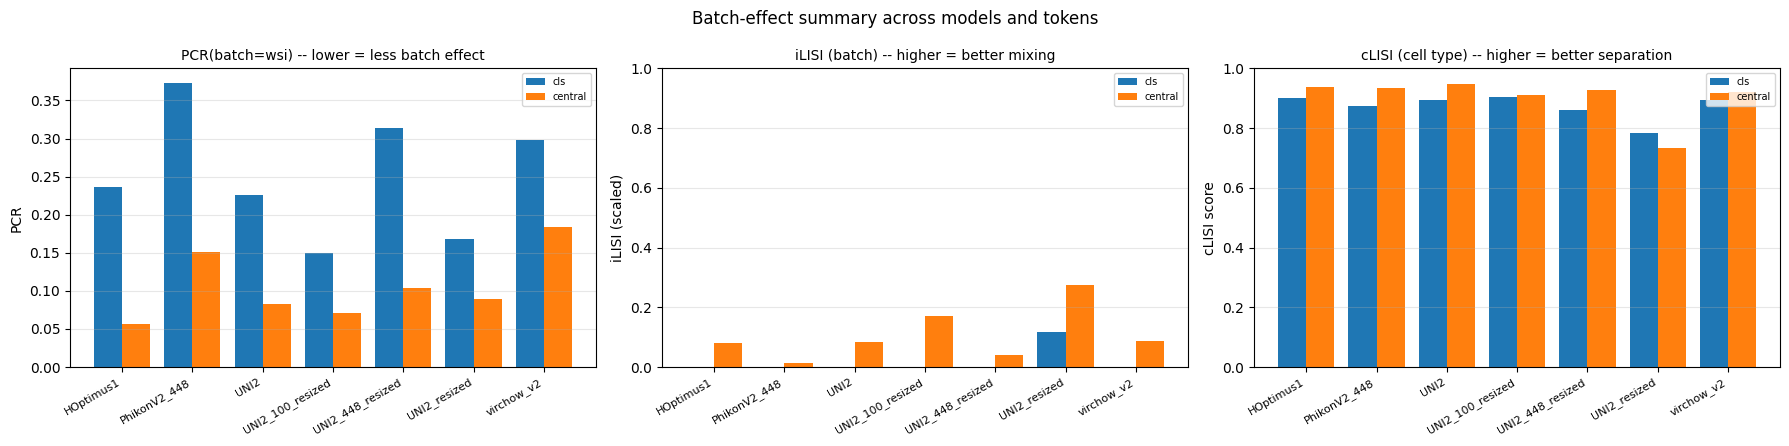

,model,token,n_cells,n_wsi,n_cell_types,pcr_batch,pcr_cell_type,ilisi_raw_median,ilisi_scaled,n_batches,clisi_raw_median,clisi_scaled,clisi_score
3,HOptimus1,central,20000,7,5,0.0561,0.0518,1.4760,0.0793,7,1.2475,0.0619,0.9381
11,UNI2_100_resized,central,20000,7,5,0.0707,0.0777,2.0306,0.1718,7,1.3506,0.0877,0.9123
5,UNI2,central,20000,7,5,0.0834,0.0935,1.5121,0.0854,7,1.2163,0.0541,0.9459
9,UNI2_resized,central,20000,7,5,0.0890,0.0156,2.6561,0.2760,7,2.0703,0.2676,0.7324
1,UNI2_448_resized,central,20000,7,5,0.1037,0.0902,1.2447,0.0408,7,1.2947,0.0737,0.9263
13,PhikonV2_448,central,20000,7,5,0.1508,0.0871,1.0911,0.0152,7,1.2699,0.0675,0.9325
7,virchow_v2,central,20000,7,5,0.1833,0.1286,1.5165,0.0861,7,1.3147,0.0787,0.9213
10,UNI2_100_resized,cls,20000,7,5,0.1500,0.0391,1.0103,0.0017,7,1.3900,0.0975,0.9025
8,UNI2_resized,cls,20000,7,5,0.1683,0.0179,1.7138,0.1190,7,1.8604,0.2151,0.7849
4,UNI2,cls,20000,7,5,0.2255,0.0353,1.0000,0.0000,7,1.4305,0.1076,0.8924


In [8]:
def grouped_bar_by_model(df: pd.DataFrame, value_col: str, title: str, ylabel: str,
                          ax=None, ylim: tuple | None = None) -> None:
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(max(6, 1.1 * df["model"].nunique()), 4))
    pivot = df.pivot_table(index="model", columns="token", values=value_col)
    pivot = pivot.reindex(columns=[t for t in TOKEN_KEYS if t in pivot.columns])
    x = np.arange(len(pivot.index))
    width = 0.8 / max(len(pivot.columns), 1)
    for i, token in enumerate(pivot.columns):
        ax.bar(x + i * width - 0.4 + width / 2, pivot[token].to_numpy(), width=width, label=token)
    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index, rotation=30, ha="right", fontsize=8)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=10)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.legend(fontsize=7)
    ax.grid(axis="y", alpha=0.3)
    if own_fig:
        fig.tight_layout()
        plt.show()


n_panels = 3 if _HAVE_LISI else 1
fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 4.5))
axes = np.atleast_1d(axes)
grouped_bar_by_model(metrics_df, "pcr_batch", "PCR(batch=wsi) -- lower = less batch effect",
                      "PCR", ax=axes[0], ylim=(0, None))
if _HAVE_LISI:
    grouped_bar_by_model(metrics_df, "ilisi_scaled", "iLISI (batch) -- higher = better mixing",
                          "iLISI (scaled)", ax=axes[1], ylim=(0, 1))
    grouped_bar_by_model(metrics_df, "clisi_score", "cLISI (cell type) -- higher = better separation",
                          "cLISI score", ax=axes[2], ylim=(0, 1))
fig.suptitle("Batch-effect summary across models and tokens")
fig.tight_layout()
plt.show()

metrics_df.sort_values(["token", "pcr_batch"]).round(4)


## Visual: PCA + UMAP, per (model, token)

For each (model, token) pair: PCA (top-2 PCs, direct) and UMAP (2D, fit on a
`pca_components_for_umap`-dim PCA pre-reduction), each colored once by `wsi`
and once by `cell_type`. Subsampled to `N_SUBSAMPLE_PLOTS` cells per panel for
speed/readability (there are up to `len(MODELS) * len(TOKEN_KEYS)` panels) --
set to `None` to use every cell. Narrow `PLOT_MODELS` / `PLOT_TOKENS` below to
render only a subset while iterating.


In [9]:
N_SUBSAMPLE_PLOTS = 5_000


def reduce_2d(X: np.ndarray, seed: int = SEED, pca_components_for_umap: int = 50):
    """Returns (pca_coords, umap_coords, pca_explained_variance_ratio). umap_coords is
    None if umap-learn isn't installed."""
    pca = PCA(n_components=2, random_state=seed).fit(X)
    pca_coords = pca.transform(X)

    umap_coords = None
    if _HAVE_UMAP:
        n_pre = min(pca_components_for_umap, X.shape[0] - 1, X.shape[1])
        pre = PCA(n_components=n_pre, random_state=seed).fit_transform(X) if n_pre < X.shape[1] else X
        umap_coords = umap.UMAP(n_components=2, random_state=seed).fit_transform(pre)

    return pca_coords, umap_coords, pca.explained_variance_ratio_


def scatter_colored(ax, coords: np.ndarray, labels: pd.Series, title: str,
                     cmap_name: str = "tab20", s: float = 5, alpha: float = 0.6) -> None:
    cats = pd.Categorical(labels)
    cmap = plt.get_cmap(cmap_name, max(len(cats.categories), 1))
    ax.scatter(coords[:, 0], coords[:, 1], c=cats.codes, cmap=cmap, s=s, alpha=alpha, linewidths=0)
    ax.set_title(title, fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
    handles = [plt.Line2D([0], [0], marker="o", linestyle="", color=cmap(i), label=str(cat))
               for i, cat in enumerate(cats.categories)]
    ax.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=6, frameon=False)


def plot_reduction_grid(model_key: str, token: str, n_subsample: int | None = N_SUBSAMPLE_PLOTS) -> None:
    data = MODEL_DATA[model_key]
    if token not in data["tokens"]:
        return
    meta_full = data["meta"]
    idx = subsample_index(len(meta_full), n_subsample)
    emb = data["tokens"][token][idx]
    meta = meta_full.iloc[idx].reset_index(drop=True)

    pca_coords, umap_coords, var_ratio = reduce_2d(emb)
    rows = [("PCA", pca_coords)] + ([("UMAP", umap_coords)] if umap_coords is not None else [])

    fig, axes = plt.subplots(len(rows), 2, figsize=(10, 4.5 * len(rows)), squeeze=False)
    for r, (method, coords) in enumerate(rows):
        extra = f" (PC1+2, {var_ratio[:2].sum():.1%} var)" if method == "PCA" else ""
        scatter_colored(axes[r][0], coords, meta["wsi"], f"{method} by wsi{extra}")
        scatter_colored(axes[r][1], coords, meta["cell_type"], f"{method} by cell_type{extra}")
    fig.suptitle(f"{model_key} / {token}  (n={len(meta):,} cells)")
    fig.tight_layout()
    plt.show()


/cluster/apps/biomed/boeva/acormoreche/conda/envs/cellViT/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


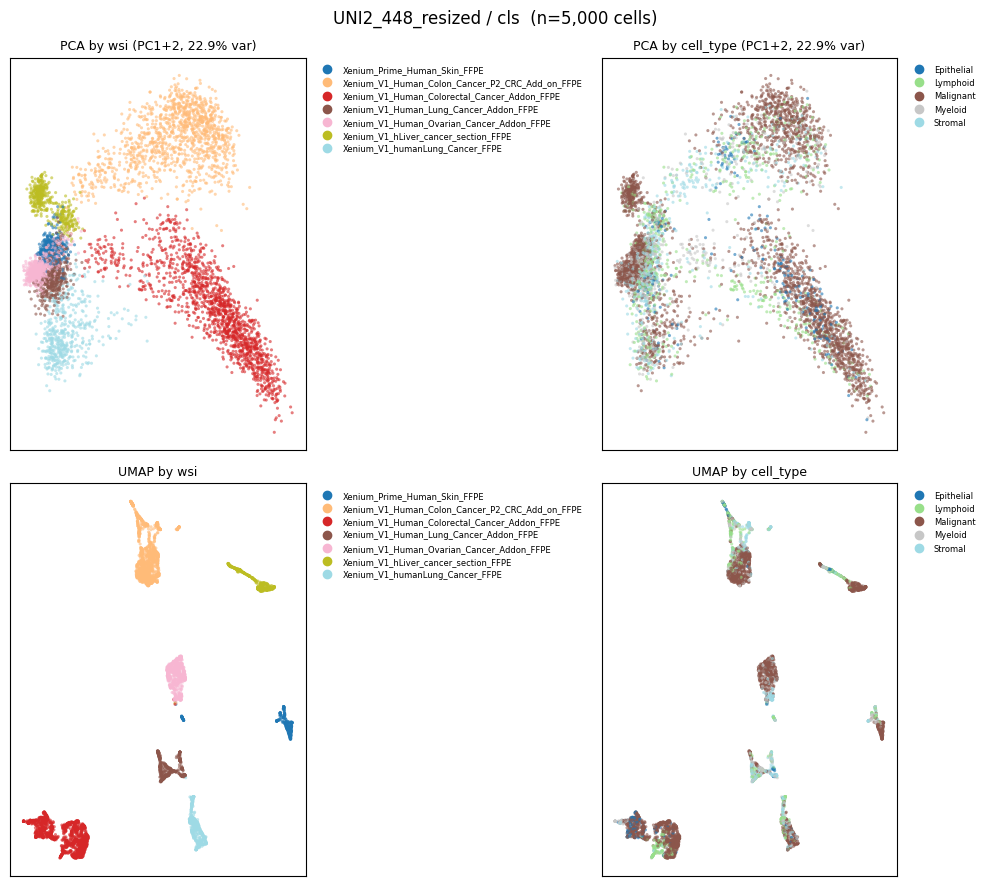

/cluster/apps/biomed/boeva/acormoreche/conda/envs/cellViT/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


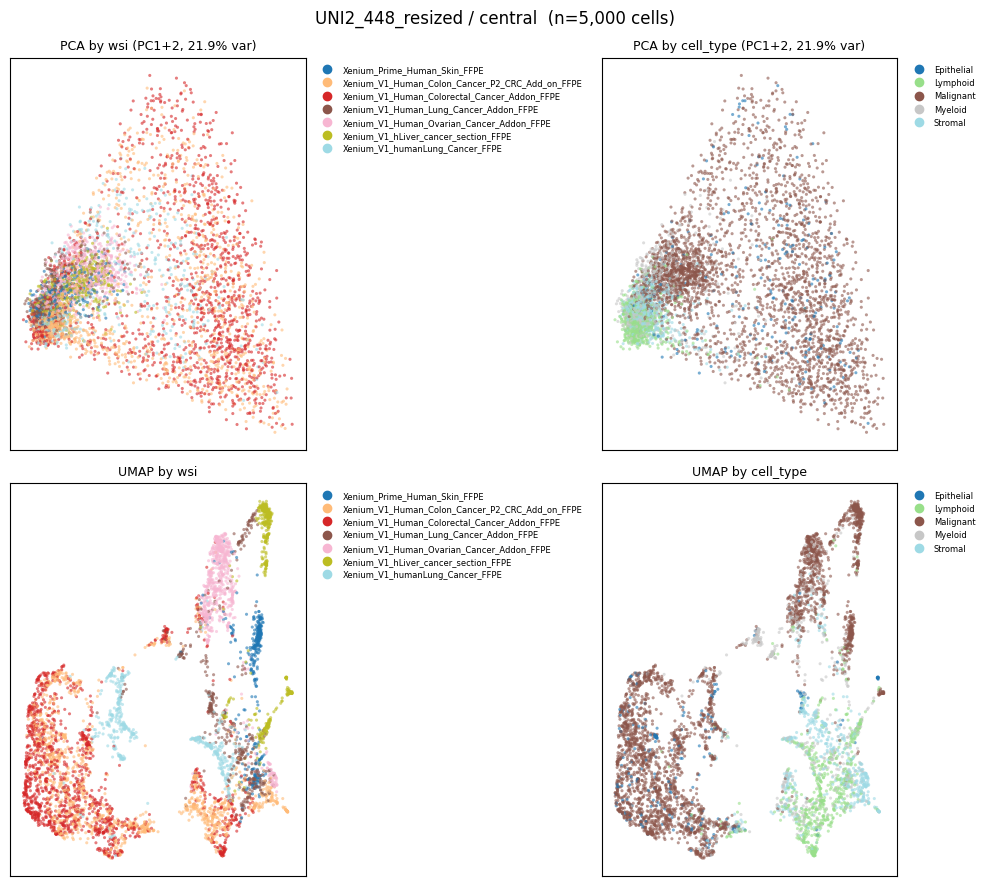

/cluster/apps/biomed/boeva/acormoreche/conda/envs/cellViT/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


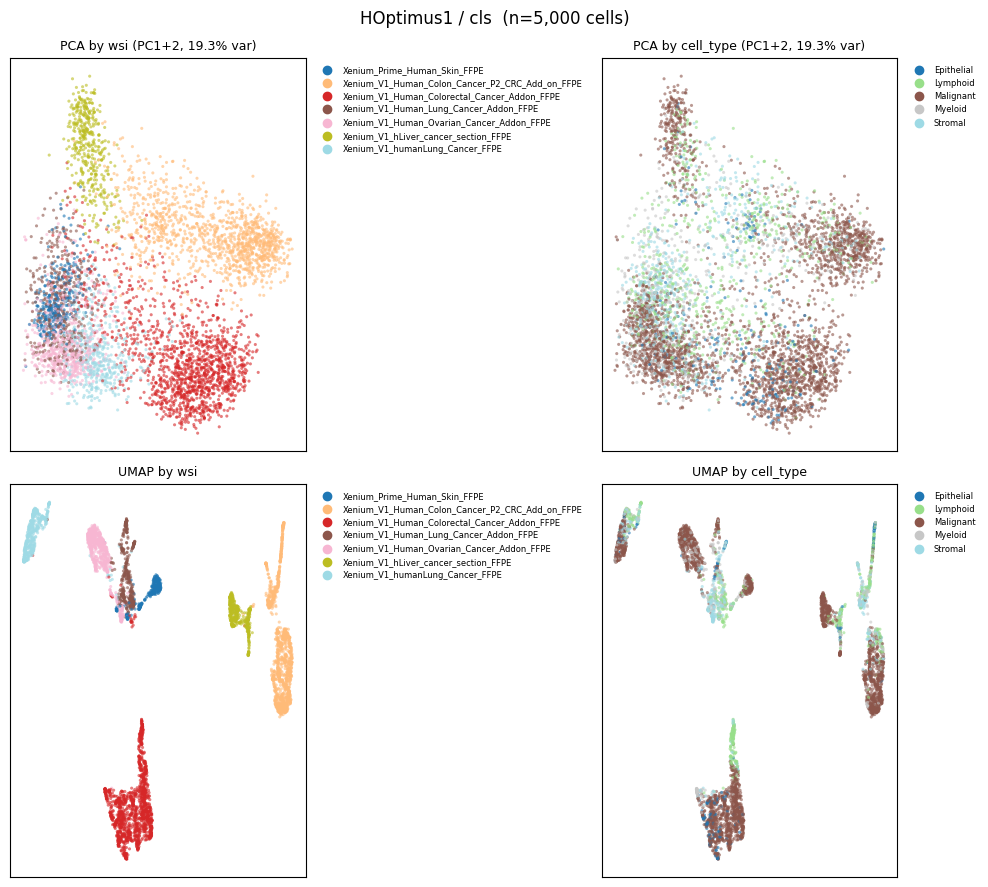

/cluster/apps/biomed/boeva/acormoreche/conda/envs/cellViT/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


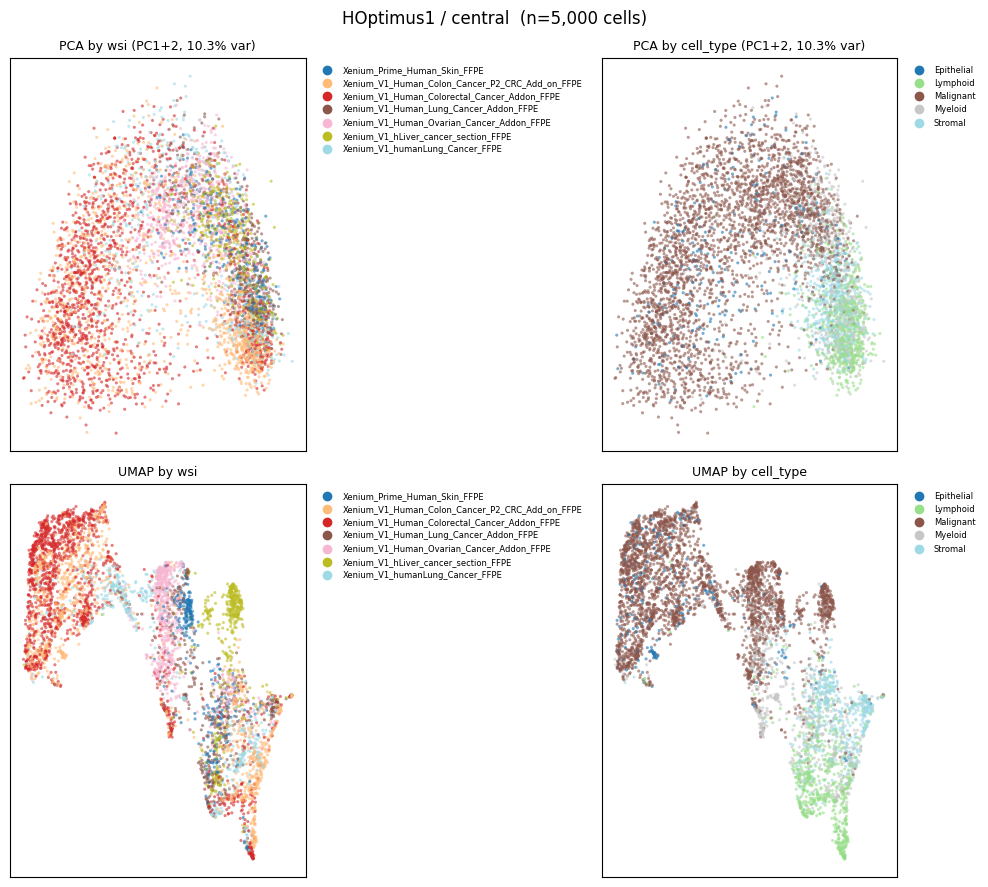

/cluster/apps/biomed/boeva/acormoreche/conda/envs/cellViT/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


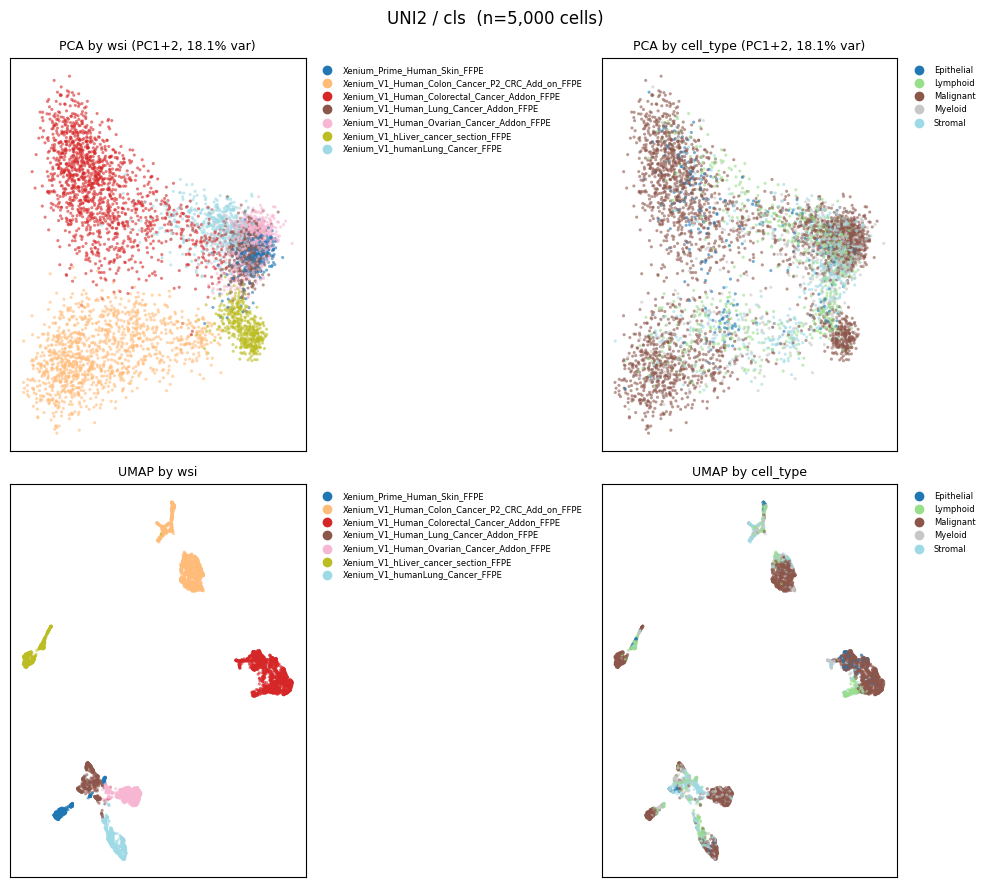

/cluster/apps/biomed/boeva/acormoreche/conda/envs/cellViT/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


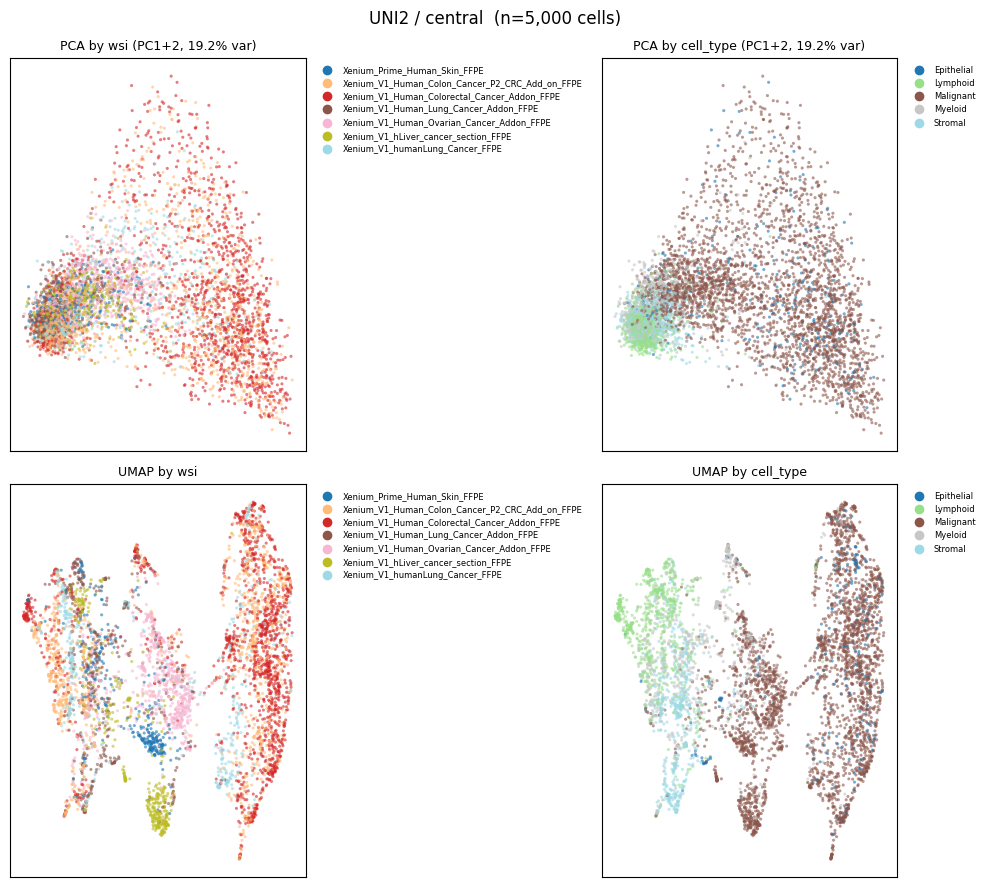

/cluster/apps/biomed/boeva/acormoreche/conda/envs/cellViT/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


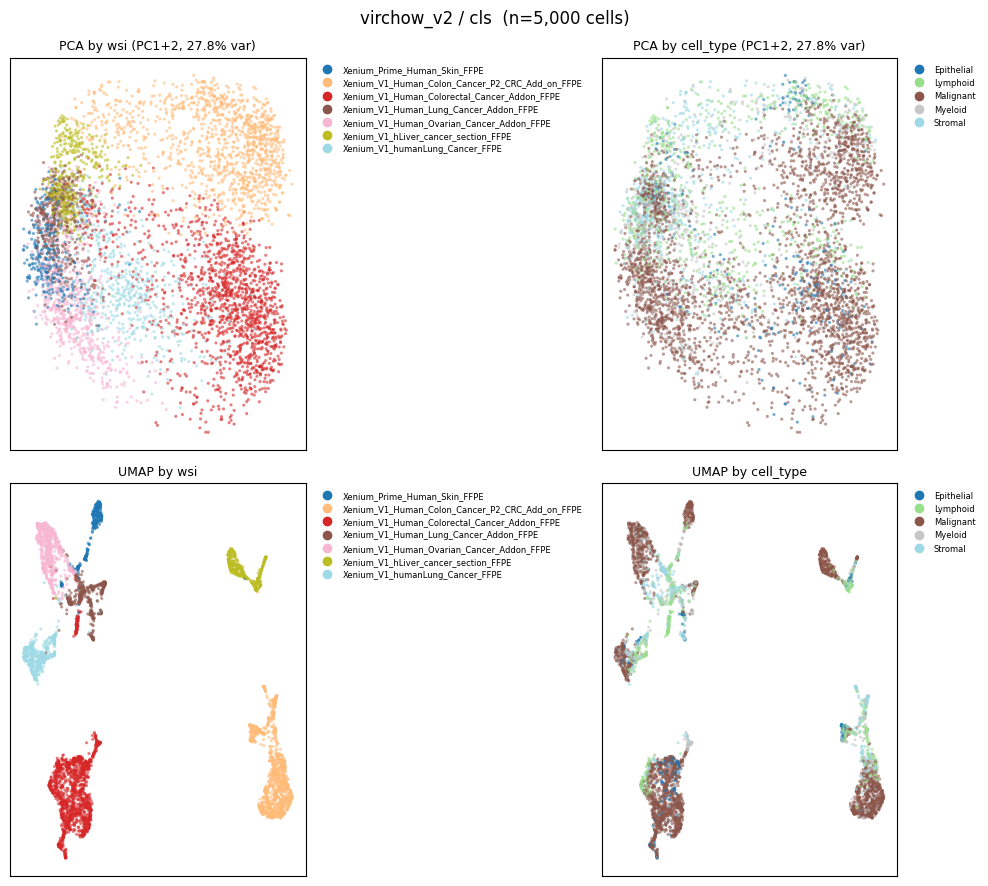

/cluster/apps/biomed/boeva/acormoreche/conda/envs/cellViT/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


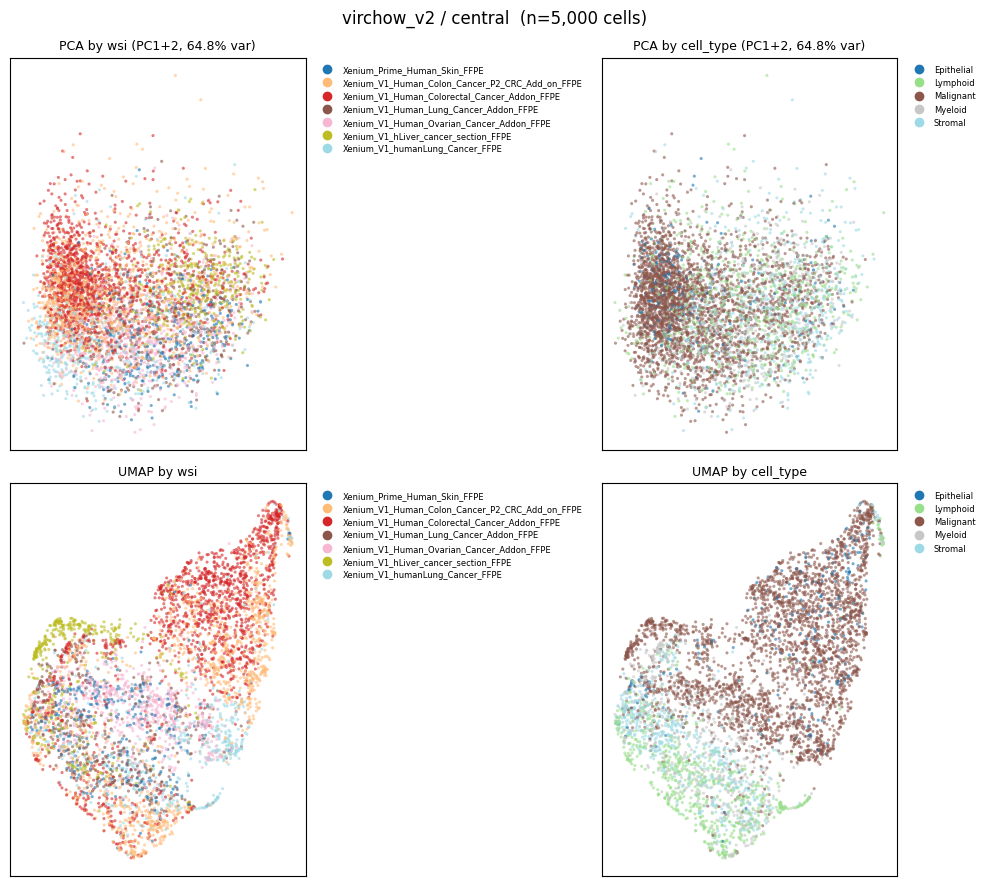

/cluster/apps/biomed/boeva/acormoreche/conda/envs/cellViT/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


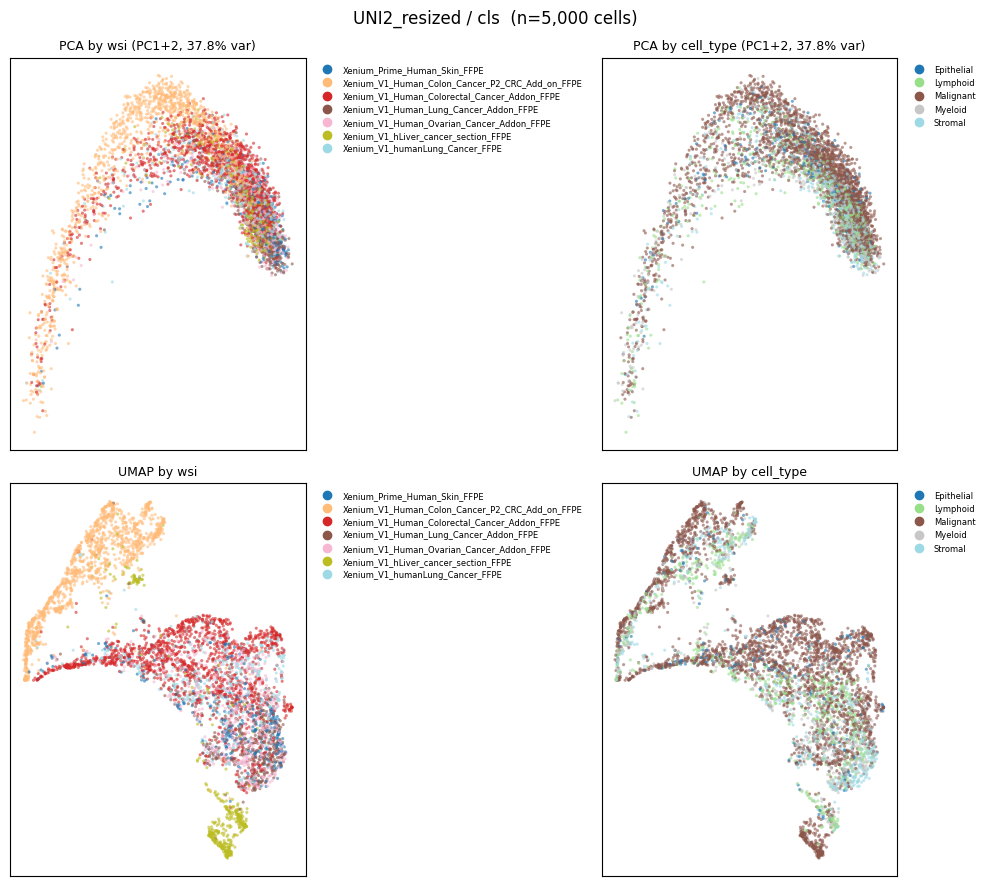

/cluster/apps/biomed/boeva/acormoreche/conda/envs/cellViT/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


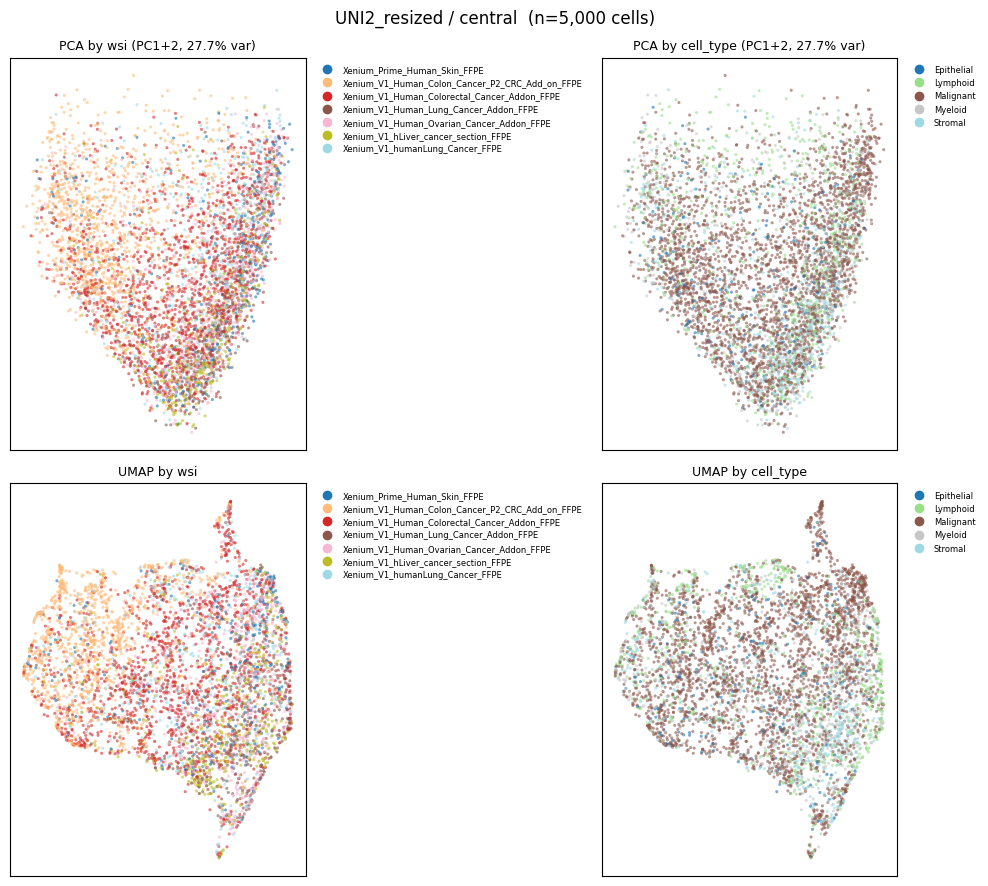

/cluster/apps/biomed/boeva/acormoreche/conda/envs/cellViT/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


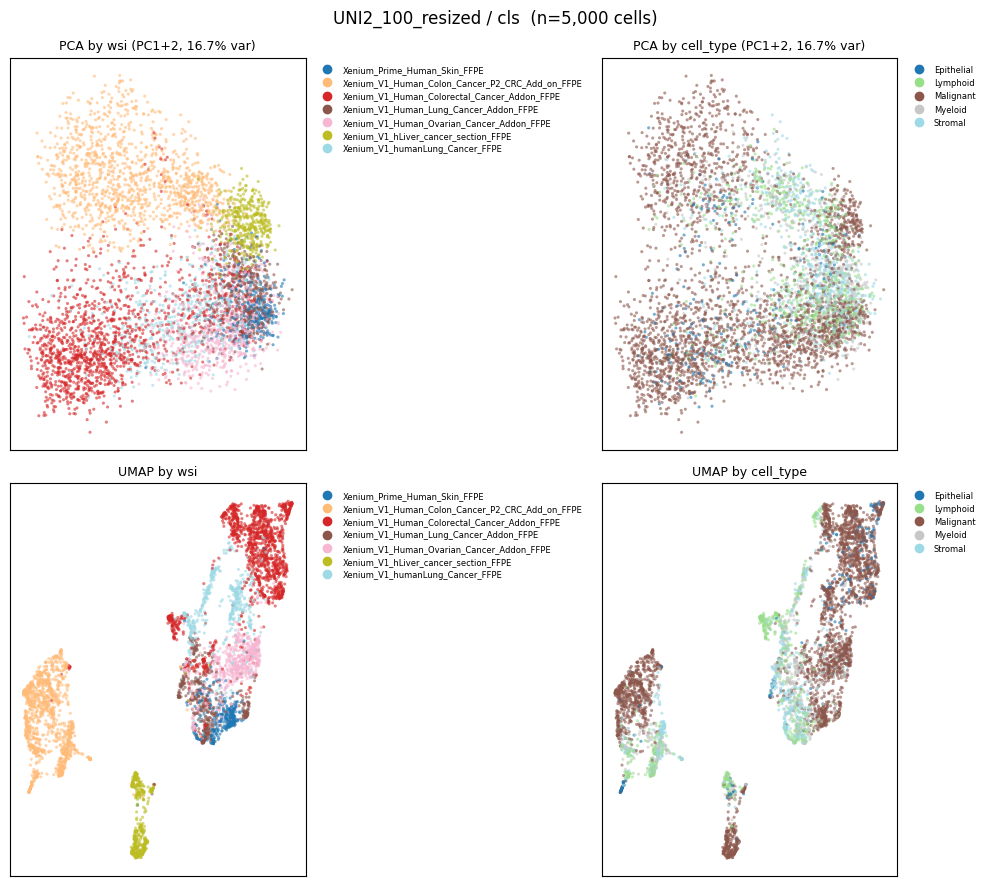

/cluster/apps/biomed/boeva/acormoreche/conda/envs/cellViT/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


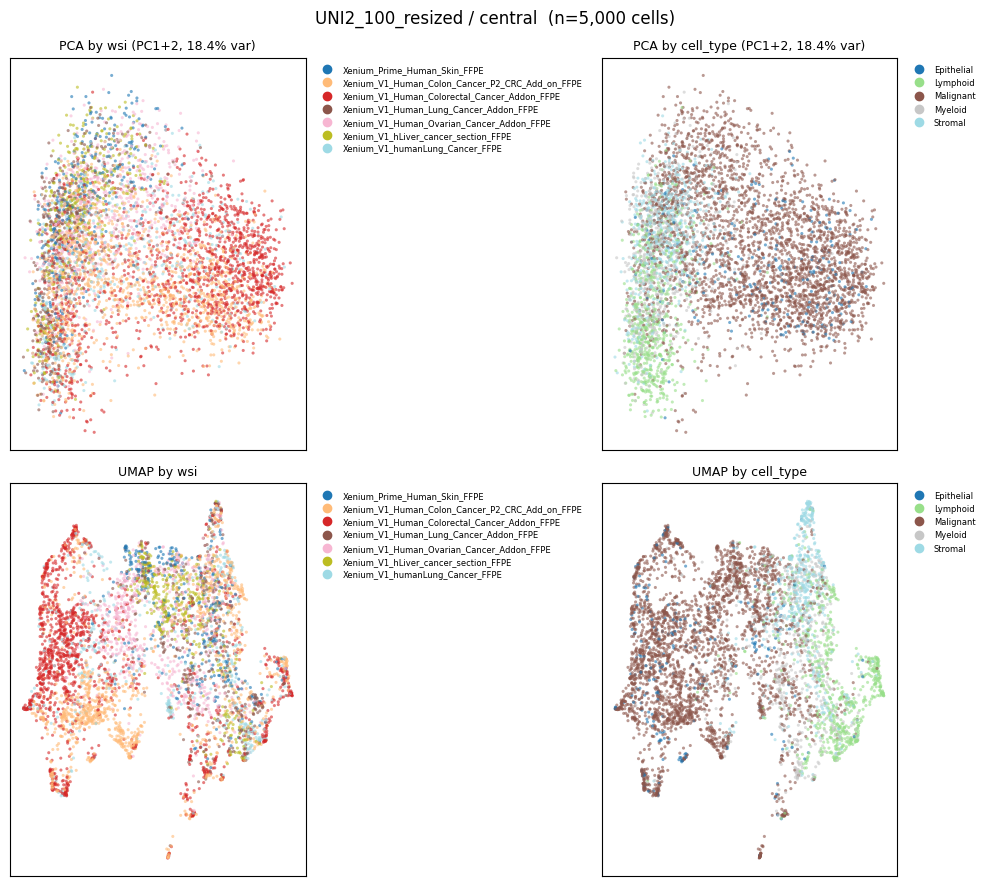

/cluster/apps/biomed/boeva/acormoreche/conda/envs/cellViT/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


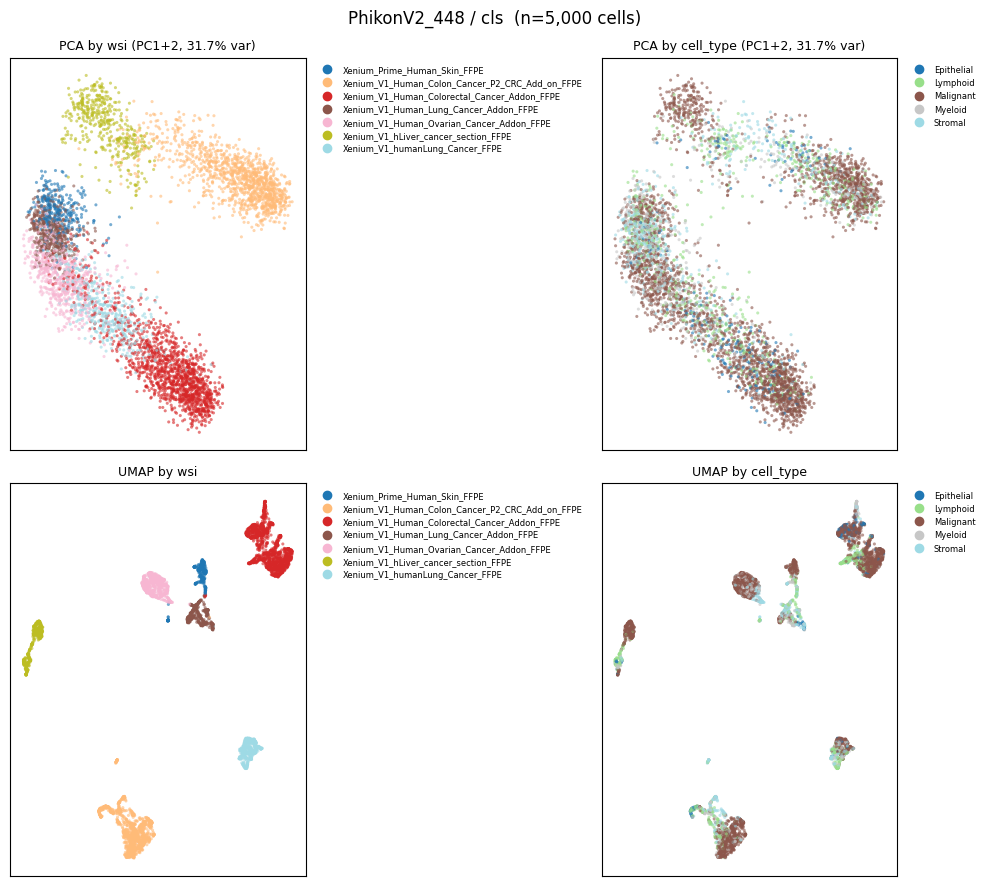

/cluster/apps/biomed/boeva/acormoreche/conda/envs/cellViT/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


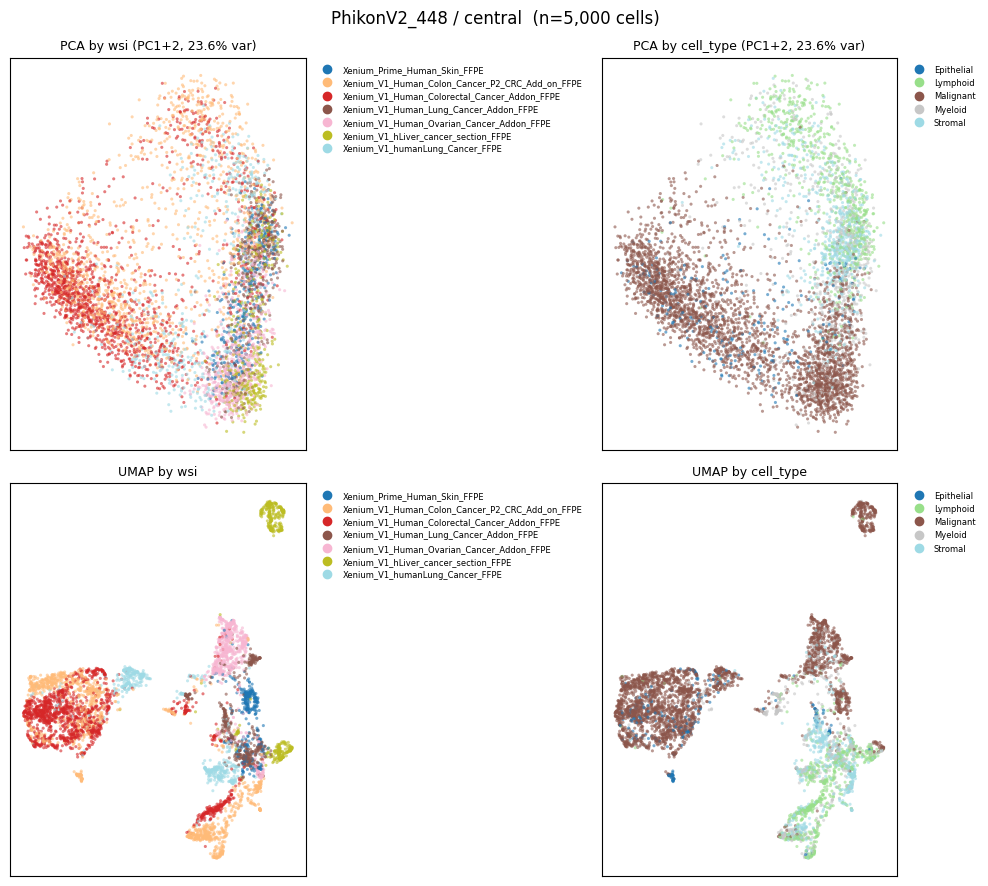

In [10]:
PLOT_MODELS = list(MODEL_DATA.keys())  # narrow this down to speed up the cell below
PLOT_TOKENS = TOKEN_KEYS               # ditto

for _model_key in PLOT_MODELS:
    for _token in PLOT_TOKENS:
        plot_reduction_grid(_model_key, _token)


## Extending this notebook

- **Another model**: add a key to `MODELS` (its `{model_output_dir}`) --
  the loading cell reports (and skips) anything missing rather than failing.
- **The four corners kept separate instead of averaged** (i.e. back to
  `top_left` / `top_right` / `bottom_left` / `bottom_right` as their own
  tokens rather than one `central`): set `TOKEN_KEYS = ["cls"] + CORNER_KEYS`
  and drop the `tokens = {k: v for k, v in tokens.items() if k in
  TOKEN_KEYS}` filter (or just add `CORNER_KEYS` to it) in the `MODEL_DATA`
  loading cell -- `add_central_token` still runs but its output is simply
  unused if `"central"` isn't in `TOKEN_KEYS`.
- **Another token**: add its raw key to `RAW_KEYS_NEEDED` and `TOKEN_KEYS` (if
  it's a raw h5 dataset) or build it the way `add_central_token` builds
  `central` (if it's derived). Both h5 files also carry boundary-pooled
  `embeddings_cell` / `embeddings_nucleus` (whole-cell / nucleus mean-pooled
  tokens, see `InferenceProvider.pool_boundary_tokens`) as raw keys.
- **A fixed WSI cohort** instead of the auto-intersected one: set `WSI_LIST`
  to an explicit list before the loading cell.
- **Different subsampling / PCA depth**: `N_SUBSAMPLE_METRICS` /
  `N_PCA_COMPS` (quantitative) and `N_SUBSAMPLE_PLOTS` (visual) trade off
  runtime against precision independently.
